## Polytope nextGEMS historical bounding box example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull nextGEMS data from LUMI and plot it using earthkit-plots.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [ ]:
import earthkit.data
import earthkit.plots

In [ ]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

In [ ]:
request = {
    'class':'ng',
    'activity':'cmip6',
    'experiment':'hist',
    'generation':'1',
    'model':'ifs-fesom',
    'realization':'1',
    'expver':'0001',
    'stream':'clte',
    'resolution':'high',
    'type':'fc',
    'levtype':'sfc',
    'date':'20000101',
    'param':'167',
    'time':'0000',
    "feature": {
        "type": "boundingbox",
        "points" : [[53.55, 2.76], [50.66, 7.86]],
    },
}

In [ ]:
data_file = "../data/nextGEMS-historical-fe-boundingbox-example.covjson"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file)

In [ ]:
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 28kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 693)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2000-01-01T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 6kB 0 1 2 3 4 5 6 ... 686 687 688 689 690 691 692
    latitude   (points) float64 6kB 50.67 50.67 50.67 ... 53.48 53.48 53.48
    longitude  (points) float64 6kB 7.784 7.145 6.931 7.571 ... 3.321 3.55 3.092
    levelist   (points) float64 6kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 6kB 275.1 ... 280.7
Attributes: (12/15)
    activity:       cmip6
    class:          ng
    Forecast date:  2000-01-01T00:00:00Z
    experiment:     hist
    expver:         0001
    generation:     1
    ...             ...
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    step:           0
    date:           2000-01-01T00:00:00Z

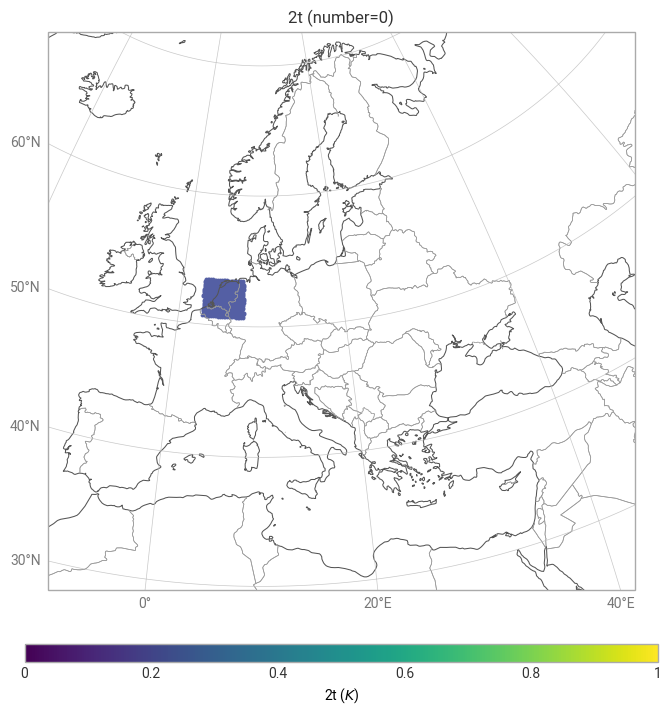

In [ ]:
chart = earthkit.plots.Map(domain="Europe")
chart.point_cloud(ds['2t'], x="longitude", y="latitude")

chart.coastlines()
chart.borders()
chart.gridlines()

chart.title("{variable_name} (number={number})")

chart.legend()

chart.show()